# WCC: astrometry in a crowded bulge field (stellar)

At 16.9 mas per pixel the WCC resolves crowded Galactic fields that ground-based seeing blends together.
This notebook renders a 10 s frame of Baade's Window with `wcc_sim` and asks **how precisely star
positions are recovered from a single frame as a function of magnitude, using the frame's own CAT
extension as truth.** Positions come from plain box centroiding (`wcc_phot.centroid.centroid_stars`,
background-subtracted centre of mass), so the numbers are a floor for that estimator, not for PSF fitting.

Install: [repository setup](../../README.md); browse the [gallery index](../README.md).

**At a glance** · Advanced · Package: `wcc_sim + wcc_phot`

- **Question:** the bold science question above; aim for one observing decision from the main comparison plot.
- **Prerequisite:** installed [gallery environment](../../README.md), basic Python and magnitudes/SNR.
- **Cost:** image arrays plus intermediates can exceed 1 GB; run alone and restart the kernel afterward.
- **First edit:** the Parameters cell below. Restart Kernel and Run All after each change.
- **Output:** plotted comparison plus printed achieved metrics/status.
- **Caveat:** recovery against a simplified simulator is not a calibrated observing-performance forecast.

Section introductions describe the original defaults; the Parameters cell and current outputs are authoritative after edits.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from wcc_etc import plot_image_mpl
from wcc_sim import simulate_field
from wcc_phot.centroid import centroid_stars

## Parameters
Change these inputs first; leave the calculation cells intact.


In [2]:
EXPOSURE = 10.0            # seconds
TIMES = [2, 5, 10, 20]    # exposure-time comparison, seconds
CENTROID_BOX = 15         # odd pixel width
SEED = 7                  # repeat with another seed to assess realization sensitivity


## 1. A 2048 px (35") subarray of Baade's Window, 10 s in the r band

In [3]:
RA, DEC = 270.9, -30.03
PLATE = 16.87                                                      # mas / px
field = simulate_field(RA, DEC, sensorfilter="zwo:r", focus=0, exptime=EXPOSURE, seed=SEED,
                       shape=(2048, 2048), cache_dir="gaia_cache")
PLATE = field.params["plate_scale_mas"]
c = field.catalog
inn = np.asarray(c["in_image"], bool); sat = np.asarray(c["saturated"], bool)
print(f"{inn.sum()} Gaia stars in frame, {(inn & sat).sum()} saturated, brightest G = {c['phot_g_mean_mag'][inn].min():.1f}")

206 Gaia stars in frame, 25 saturated, brightest G = 11.3


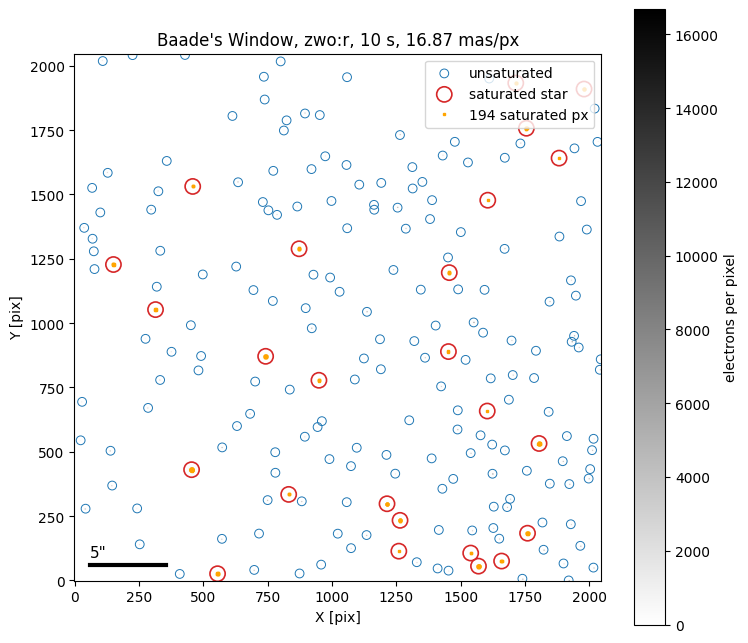

In [4]:
img = field.image_e                                                # electrons
fig, ax = plt.subplots(figsize=(8.5, 8))
plot_image_mpl(image_e=img, saturation_mask=field.saturation_mask, pixel_scale_mas=PLATE,
               show_saturation=True, stretch="asinh", cmap="gray_r", ax=ax)
ax.figure.axes[-1].set_ylabel("electrons per pixel")
ax.scatter(c["x"][inn & ~sat], c["y"][inn & ~sat], s=40, facecolors="none", edgecolors="C0", lw=0.7, label="unsaturated")
ax.scatter(c["x"][inn & sat], c["y"][inn & sat], s=120, facecolors="none", edgecolors="C3", lw=1.2, label="saturated star")
ys, xs = np.nonzero(field.saturation_mask)
ax.plot(xs, ys, "s", ms=2, color="orange", label=f"{xs.size} saturated px")
bar = 5000 / PLATE                                                 # 5" scale bar in px
ax.plot([60, 60 + bar], [60, 60], "k-", lw=3); ax.text(60, 90, '5"', fontsize=11)
ax.legend(loc="upper right"); ax.set_title(f"Baade's Window, zwo:r, {EXPOSURE:g} s, {PLATE:.2f} mas/px")
plt.show()


## 2. Re-centroid every unsaturated star and compare with the catalog

`hypot(dx, dy)` is a **radial** residual; per-coordinate scatter and mean offset (bias) are reported
separately, and flagged centroids (failed or runaway, `flags > 0`) are rejected. For isotropic, unbiased
Gaussian errors the median radial residual is `sqrt(2 ln 2) * sigma_coord = 1.18 sigma_coord`.


174 stars centroided, 0 flagged and rejected, 174 kept
per-coordinate scatter sigma_x = 0.56, sigma_y = 0.50 mas; mean offset dx = +0.04, dy = +0.03 mas
median radial residual 0.66 mas vs sqrt(2 ln 2) sigma = 0.62 mas
G bin centres: [13.5 14.5 15.5 16.5 17.5 18.5 19.5 20.5] 
per-coordinate sigma [mas]: [ nan  nan 0.3  0.47 0.48 0.6  0.57  nan] 
stars per bin: [0, 0, 3, 50, 53, 59, 9, 0]


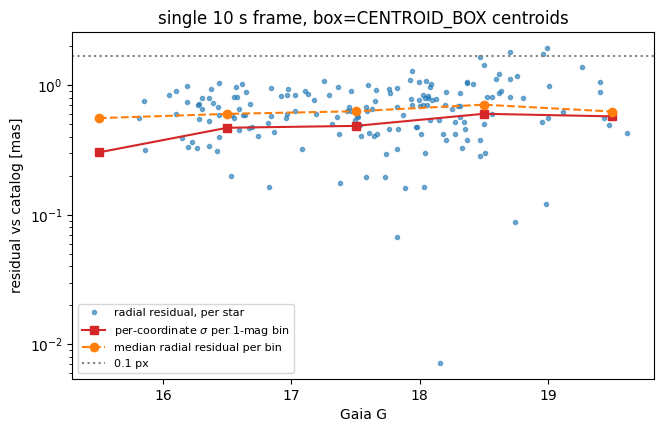

In [5]:
use = inn & ~sat & (c["x"] > 20) & (c["x"] < field.image_e.shape[1] - 21) & (c["y"] > 20) & (c["y"] < field.image_e.shape[0] - 21)
x, y, flags = centroid_stars(field, c["x"][use], c["y"][use], box=CENTROID_BOX)
good = (flags == 0) & np.isfinite(x) & np.isfinite(y)
assert good.sum() >= 3, "Too few valid centroids for a scatter estimate"
dx = (x - c["x"][use])[good] * PLATE; dy = (y - c["y"][use])[good] * PLATE      # mas
res = np.hypot(dx, dy)                                                            # radial residual, mas
g = np.asarray(c["phot_g_mean_mag"][use])[good]
sig = 0.5 * (dx.std() + dy.std())
print(f"{use.sum()} stars centroided, {int((~good).sum())} flagged and rejected, {good.sum()} kept")
print(f"per-coordinate scatter sigma_x = {dx.std():.2f}, sigma_y = {dy.std():.2f} mas; "
      f"mean offset dx = {dx.mean():+.2f}, dy = {dy.mean():+.2f} mas")
print(f"median radial residual {np.median(res):.2f} mas vs sqrt(2 ln 2) sigma = {np.sqrt(2 * np.log(2)) * sig:.2f} mas")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.semilogy(g, res, ".", alpha=0.6, label="radial residual, per star")
edges = np.arange(13, 21.5, 1)
mid = 0.5 * (edges[1:] + edges[:-1])
inb = [(g >= a) & (g < b) for a, b in zip(edges[:-1], edges[1:])]
sig_bin = [0.5 * (dx[m].std() + dy[m].std()) if m.sum() > 2 else np.nan for m in inb]
med_bin = [np.median(res[m]) if m.sum() > 2 else np.nan for m in inb]
print("G bin centres:", mid, "\nper-coordinate sigma [mas]:", np.round(sig_bin, 2), "\nstars per bin:", [int(m.sum()) for m in inb])
ax.plot(mid, sig_bin, "s-", color="C3", label="per-coordinate $\\sigma$ per 1-mag bin")
ax.plot(mid, med_bin, "o--", color="C1", label="median radial residual per bin")
ax.axhline(PLATE / 10, color="0.5", ls=":", label="0.1 px")
ax.set(xlabel="Gaia G", ylabel="residual vs catalog [mas]", title="single 10 s frame, box=CENTROID_BOX centroids"); ax.legend(fontsize=8)
plt.show()


## 3. Astrometric precision versus exposure time

Stars with 17 < G < 19, which stay unsaturated out to 20 s. Per-coordinate scatter (pooled x and y, flagged
centroids rejected) is plotted; the mean offset is printed alongside because a bias does not average down
with more frames the way the scatter does.


  2 s: 112 stars, 0 flagged; per-coordinate sigma 1.08 mas, |mean offset| 0.12 mas


  5 s: 112 stars, 0 flagged; per-coordinate sigma 0.67 mas, |mean offset| 0.02 mas


 10 s: 112 stars, 0 flagged; per-coordinate sigma 0.55 mas, |mean offset| 0.03 mas


 20 s: 112 stars, 0 flagged; per-coordinate sigma 0.50 mas, |mean offset| 0.07 mas


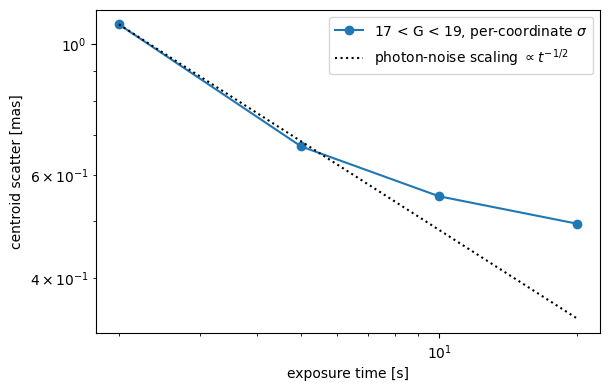

In [6]:
times = TIMES
sig_t, bias_t = [], []
for t in times:
    f = simulate_field(RA, DEC, sensorfilter="zwo:r", focus=0, exptime=t, seed=SEED, shape=(2048, 2048), cache_dir="gaia_cache")
    ct = f.catalog
    sel = (np.asarray(ct["in_image"], bool) & ~np.asarray(ct["saturated"], bool)
           & (ct["phot_g_mean_mag"] > 17) & (ct["phot_g_mean_mag"] < 19)
           & (ct["x"] > 20) & (ct["x"] < field.image_e.shape[1] - 21) & (ct["y"] > 20) & (ct["y"] < f.image_e.shape[0] - 21))
    xt, yt, ft = centroid_stars(f, ct["x"][sel], ct["y"][sel], box=CENTROID_BOX)
    gd = (ft == 0) & np.isfinite(xt) & np.isfinite(yt)
    if gd.sum() < 3:
        sig_t.append(np.nan); bias_t.append(np.nan)
        print(f"{t:g} s: fewer than three valid centroids; omitted")
        continue
    d = np.concatenate([(xt - ct["x"][sel])[gd], (yt - ct["y"][sel])[gd]]) * PLATE   # pooled x and y, mas
    sig_t.append(d.std()); bias_t.append(PLATE * np.hypot((xt - ct["x"][sel])[gd].mean(), (yt - ct["y"][sel])[gd].mean()))
    print(f"{t:3g} s: {sel.sum()} stars, {int((~gd).sum())} flagged; per-coordinate sigma {sig_t[-1]:.2f} mas, |mean offset| {bias_t[-1]:.2f} mas")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.loglog(times, sig_t, "o-", label="17 < G < 19, per-coordinate $\\sigma$")
ax.loglog(times, sig_t[0] * np.sqrt(times[0] / np.array(times)), "k:", label="photon-noise scaling $\\propto t^{-1/2}$")
ax.set(xlabel="exposure time [s]", ylabel="centroid scatter [mas]"); ax.legend()
plt.show()


## Reference-run takeaway (original defaults)

**Historical baseline prose:** numerical values below describe the pre-review default run. Use the freshly printed values and plots for current results, especially where this revision corrects an estimator.

The current plots measure centroid recovery against the simulator's own catalog truth. Scatter and mean offsets are both in mas; radial residual and per-coordinate scatter are different statistics. This is not an absolute-astrometry forecast: unresolved/faint populations missing from Gaia, distortion, pointing, calibration and PSF mismatch are not modeled. Repeat with several seeds and matched stars before attributing a flattening uniquely to crowding or the estimator.


## Try this

1. Set SEED to 11. Report how much the apparent exposure-time floor changes.
2. Set CENTROID_BOX to 11. Compare scatter, mean offset and rejected stars.

**Extension:** Use matched stars and multiple realizations before inferring a physical precision floor.

Bring back one figure, the requested and achieved metric, an observing decision, and the main limitation.
